# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Online_Retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:

df.duplicated().sum()

np.int64(5268)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [13]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [14]:
df.shape

(527390, 8)

In [15]:
df[df["Quantity"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,01-12-2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,02-12-2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,03-12-2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,03-12-2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,03-12-2010 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,07-12-2011 18:36,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,07-12-2011 18:38,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,07-12-2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,08-12-2011 09:56,0.0,NaN,United Kingdom


In [16]:
(df["Quantity"] <= 0).sum()

np.int64(1336)

In [17]:
df = df[df["Quantity"] > 0]

In [18]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,07-12-2011 18:36,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,08-12-2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,08-12-2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,08-12-2011 13:58,0.0,NaN,United Kingdom


#Invalid Unit Price

In [19]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,07-12-2011 18:36,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,08-12-2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,08-12-2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,08-12-2011 13:58,0.0,NaN,United Kingdom


In [20]:
(df["UnitPrice"] <= 0).sum()

np.int64(1176)

In [21]:
df = df[df["UnitPrice"] > 0]

#Missing Customer IDs

In [22]:
df["CustomerID"].isnull().sum()

np.int64(132186)

In [23]:
df = df.dropna(subset=["CustomerID"])

#Check Data Types

In [24]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [31]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%d-%m-%Y %H:%M'
)

#Outliers

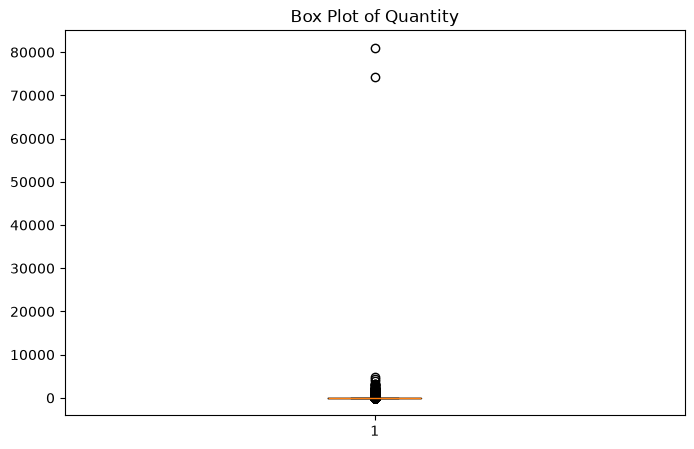

In [32]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Quantity"])
plt.title("Box Plot of Quantity")
plt.show()

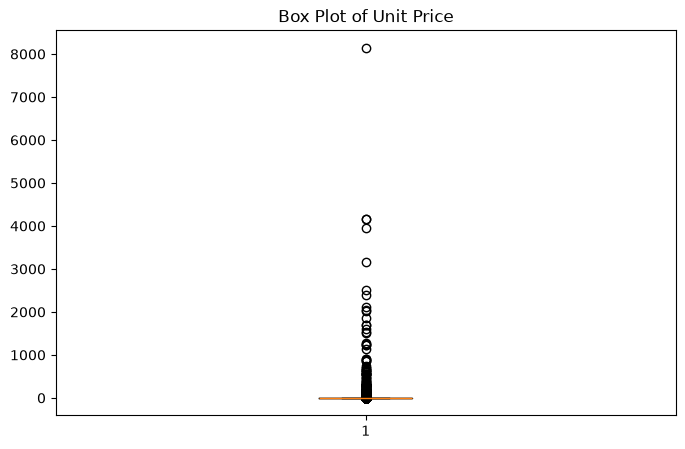

In [33]:
plt.figure(figsize=(8,5))
plt.boxplot(df["UnitPrice"])
plt.title("Box Plot of Unit Price")
plt.show()

#Total Amount

In [34]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [35]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#Seperating time and date


In [36]:
df["Date"] = df["InvoiceDate"].dt.date
df["Time"] = df["InvoiceDate"].dt.time

In [37]:
df[["InvoiceDate", "Date", "Time"]].head()

,InvoiceDate,Date,Time
0,2010-12-01 08:26:00,2010-12-01,08:26:00
1,2010-12-01 08:26:00,2010-12-01,08:26:00
2,2010-12-01 08:26:00,2010-12-01,08:26:00
3,2010-12-01 08:26:00,2010-12-01,08:26:00
4,2010-12-01 08:26:00,2010-12-01,08:26:00


In [38]:
df.drop(columns=["InvoiceDate"], inplace=True)

In [39]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice',
       'CustomerID', 'Country', 'TotalAmount', 'Date', 'Time'],
      dtype='str')

In [40]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [41]:
df = df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "Date",
        "Time",
        "UnitPrice",
        "TotalAmount",
        "CustomerID",
        "Country"
    ]
]

In [42]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'Date', 'Time',
       'UnitPrice', 'TotalAmount', 'CustomerID', 'Country'],
      dtype='str')

In [43]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom


In [44]:
invoice_group = df.groupby("InvoiceNo")

In [45]:
invoice_group.get_group(df["InvoiceNo"].iloc[0])

,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01,08:26:00,7.65,15.30,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01,08:26:00,4.25,25.50,17850.0,United Kingdom


In [47]:
display_df = df.sort_values(by=["CustomerID", "InvoiceNo"]).copy()

display_df["CustomerID"] = display_df["CustomerID"].astype(str)

display_df.loc[
    display_df["CustomerID"].duplicated(),
    "CustomerID"
] = ""

display_df.head(20)

,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18,10:01:00,1.04,77183.6,12346.0,United Kingdom
14938,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,2010-12-07,14:57:00,2.10,25.2,12347.0,Iceland
14939,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,2010-12-07,14:57:00,4.25,17.0,,Iceland
14940,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,2010-12-07,14:57:00,3.25,39.0,,Iceland
14941,537626,22492,MINI PAINT SET VINTAGE,36,2010-12-07,14:57:00,0.65,23.4,,Iceland
14942,537626,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,12,2010-12-07,14:57:00,1.25,15.0,,Iceland
14943,537626,22772,PINK DRAWER KNOB ACRYLIC EDWARDIAN,12,2010-12-07,14:57:00,1.25,15.0,,Iceland
14944,537626,22773,GREEN DRAWER KNOB ACRYLIC EDWARDIAN,12,2010-12-07,14:57:00,1.25,15.0,,Iceland
14945,537626,22774,RED DRAWER KNOB ACRYLIC EDWARDIAN,12,2010-12-07,14:57:00,1.25,15.0,,Iceland
14946,537626,22775,PURPLE DRAWERKNOB ACRYLIC EDWARDIAN,12,2010-12-07,14:57:00,1.25,15.0,,Iceland


In [48]:
df = df[
    [
        "CustomerID",
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "Date",
        "Time",
        "UnitPrice",
        "TotalAmount",
        "Country"
    ]
]

In [49]:
df.head(30)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,Country
0,17850.0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,United Kingdom
1,17850.0,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
2,17850.0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,United Kingdom
3,17850.0,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
4,17850.0,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
5,17850.0,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01,08:26:00,7.65,15.30,United Kingdom
6,17850.0,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01,08:26:00,4.25,25.50,United Kingdom
7,17850.0,536366,22633,HAND WARMER UNION JACK,6,2010-12-01,08:28:00,1.85,11.10,United Kingdom
8,17850.0,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01,08:28:00,1.85,11.10,United Kingdom
9,13047.0,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01,08:34:00,1.69,54.08,United Kingdom


In [50]:
df.to_csv("Cleaned_Online_Retail.csv", index=False)

In [51]:
df.shape


(392692, 10)

# EDA

In [4]:
import pandas as pd

df = pd.read_csv("Cleaned_Online_Retail.csv")
df.head()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,Country
0,17850.0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,United Kingdom
1,17850.0,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
2,17850.0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,United Kingdom
3,17850.0,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
4,17850.0,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom


In [5]:
df.shape

(392692, 10)

In [6]:
df.columns

Index(['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'Date', 'Time', 'UnitPrice', 'TotalAmount', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   392692 non-null  float64
 1   InvoiceNo    392692 non-null  int64  
 2   StockCode    392692 non-null  str    
 3   Description  392692 non-null  str    
 4   Quantity     392692 non-null  int64  
 5   Date         392692 non-null  str    
 6   Time         392692 non-null  str    
 7   UnitPrice    392692 non-null  float64
 8   TotalAmount  392692 non-null  float64
 9   Country      392692 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 30.0 MB


In [8]:
df.describe()

,CustomerID,InvoiceNo,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,15287.843865,560590.875047,13.119702,3.125914,22.631500
std,1713.539549,13087.063759,180.492832,22.241836,311.099224
min,12346.000000,536365.000000,1.000000,0.001000,0.001000
25%,13955.000000,549234.000000,2.000000,1.250000,4.950000
50%,15150.000000,561874.000000,6.000000,1.950000,12.450000
75%,16791.000000,572061.000000,12.000000,3.750000,19.800000
max,18287.000000,581587.000000,80995.000000,8142.750000,168469.600000


In [9]:
df.describe()

,CustomerID,InvoiceNo,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,15287.843865,560590.875047,13.119702,3.125914,22.631500
std,1713.539549,13087.063759,180.492832,22.241836,311.099224
min,12346.000000,536365.000000,1.000000,0.001000,0.001000
25%,13955.000000,549234.000000,2.000000,1.250000,4.950000
50%,15150.000000,561874.000000,6.000000,1.950000,12.450000
75%,16791.000000,572061.000000,12.000000,3.750000,19.800000
max,18287.000000,581587.000000,80995.000000,8142.750000,168469.600000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

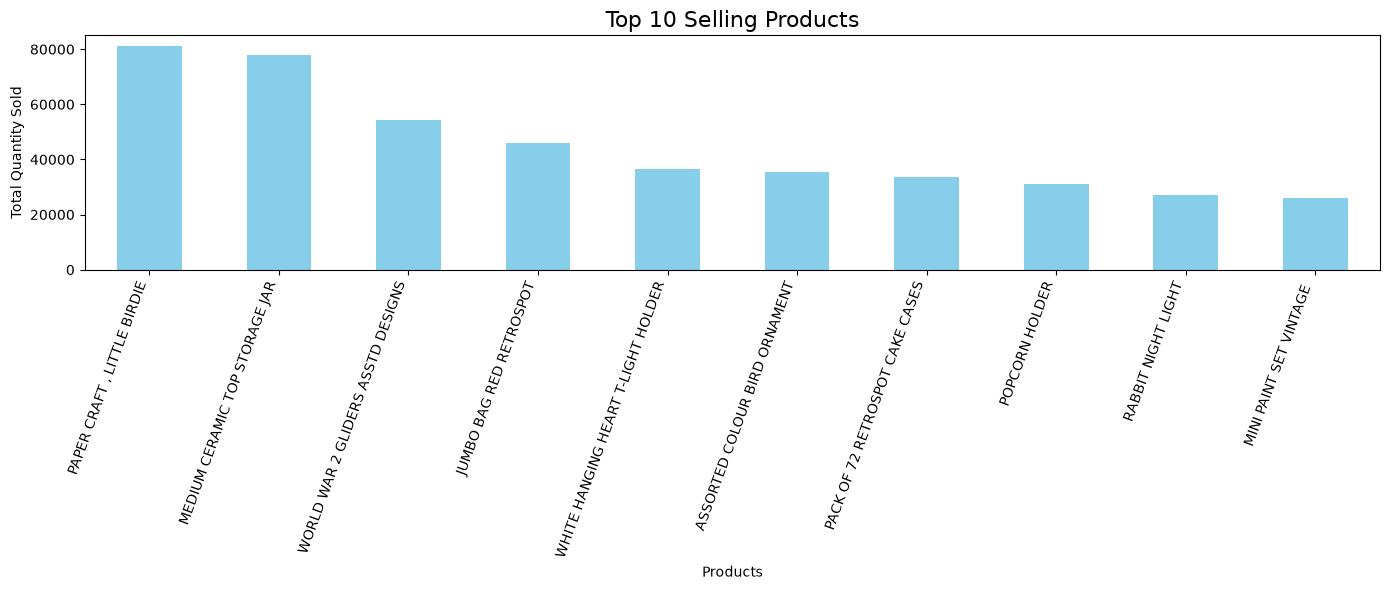

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

top_products.plot(kind='bar', color='skyblue')

plt.title("Top 10 Selling Products", fontsize=16)
plt.xlabel("Products")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

In [16]:
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

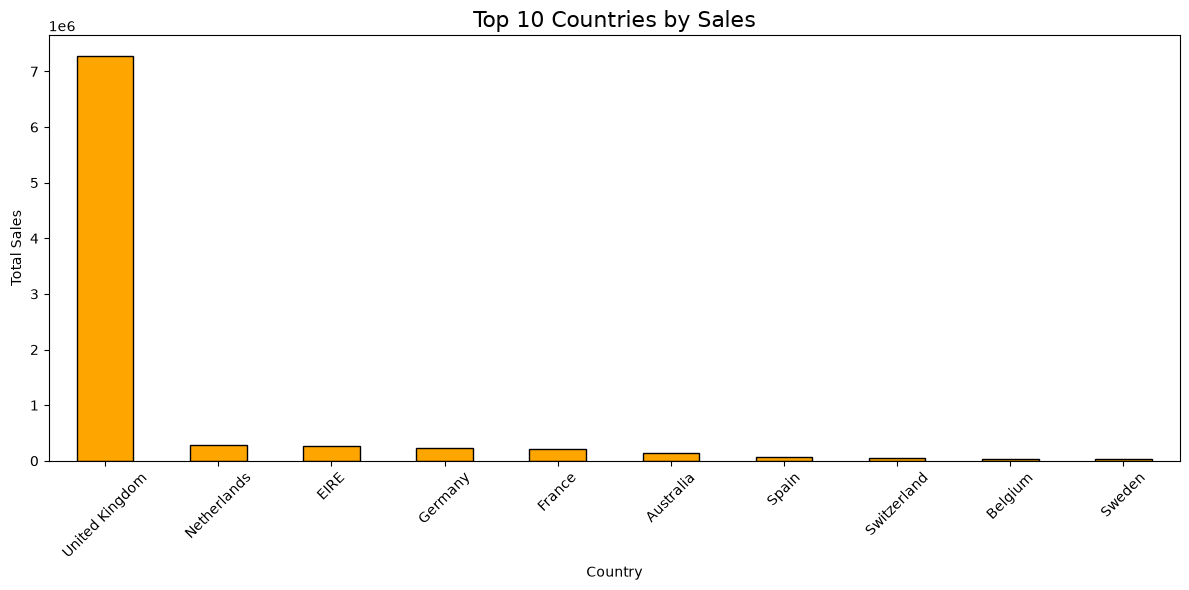

In [17]:
plt.figure(figsize=(12,6))
country_sales.head(10).plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)
plt.title("Top 10 Countries by Sales", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
#Monthly Sales Trend
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
df["Month"] = df["Date"].dt.to_period("M")

In [20]:
monthly_sales = df.groupby("Month")["TotalAmount"].sum()
monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalAmount, dtype: float64

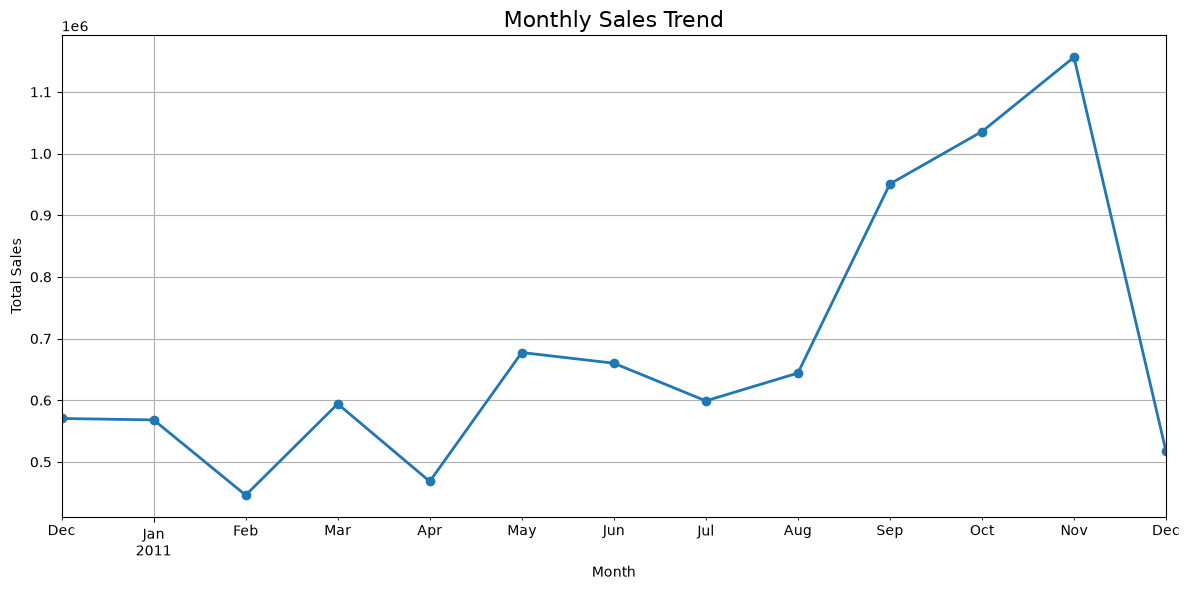

In [21]:
plt.figure(figsize=(12,6))
monthly_sales.plot(
    marker='o',
    linewidth=2
)
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
#Top 10 Customers
top_customers = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalAmount, dtype: float64

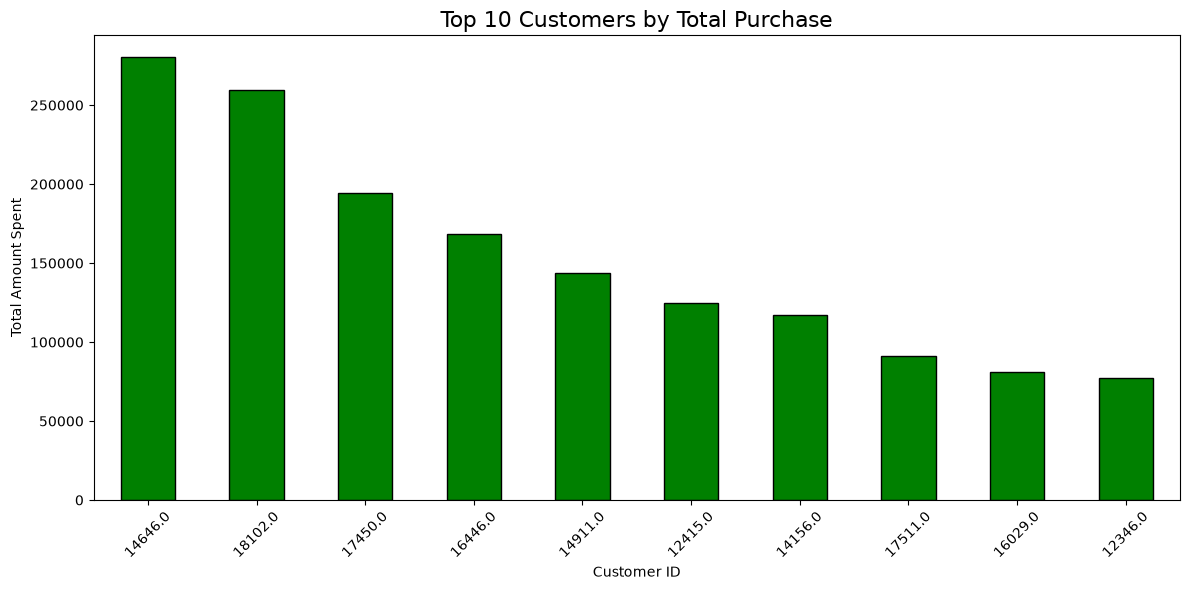

In [23]:
plt.figure(figsize=(12,6))
top_customers.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)
plt.title("Top 10 Customers by Total Purchase", fontsize=16)
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

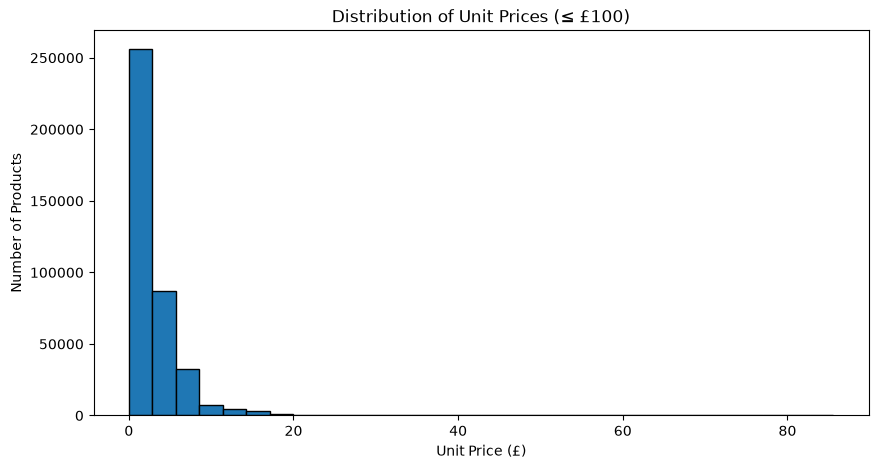

In [24]:
#Unit Price Distribution
plt.figure(figsize=(10,5))

plt.hist(df[df["UnitPrice"] <= 100]["UnitPrice"],
         bins=30,
         edgecolor="black")

plt.title("Distribution of Unit Prices (≤ £100)")
plt.xlabel("Unit Price (£)")
plt.ylabel("Number of Products")

plt.show()

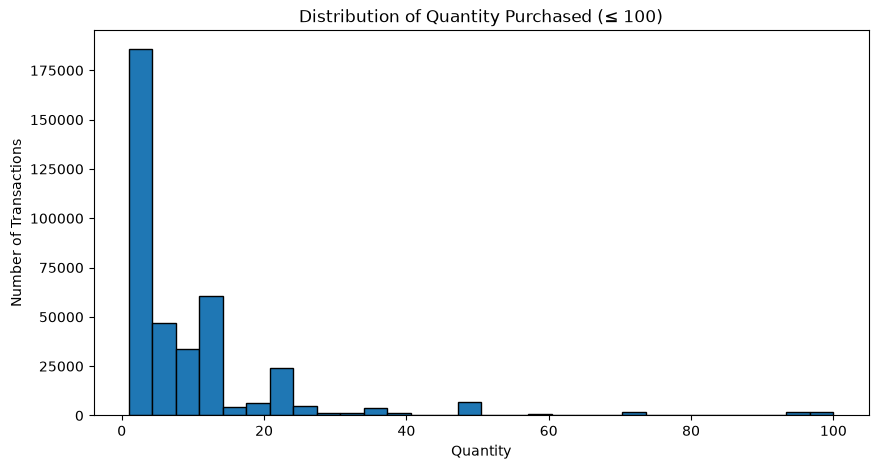

In [25]:
#Quantity Distribution
plt.figure(figsize=(10,5))
plt.hist(df[df["Quantity"] <= 100]["Quantity"],
         bins=30,
         edgecolor="black")

plt.title("Distribution of Quantity Purchased (≤ 100)")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.show()

In [26]:
#Top Products by Revenue
top_revenue = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64

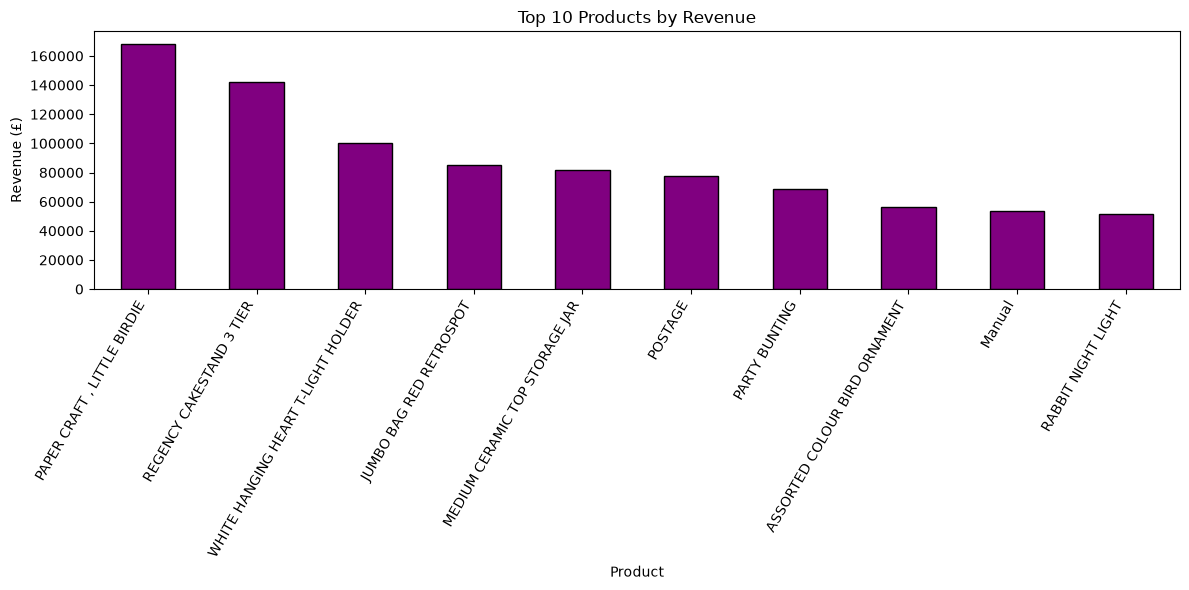

In [27]:
plt.figure(figsize=(12,6))

top_revenue.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

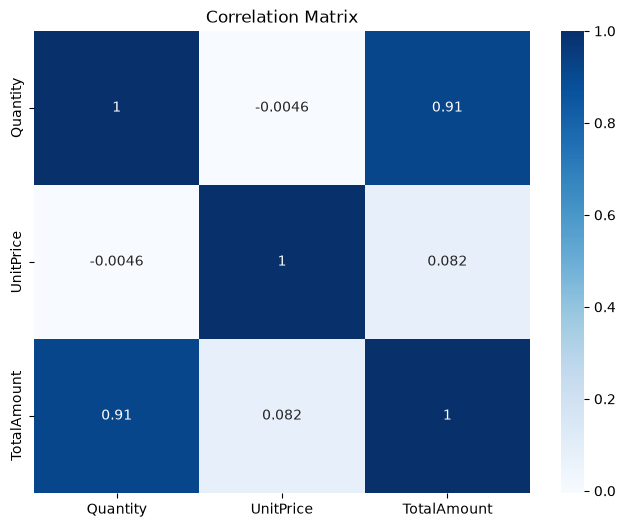

In [29]:
#Correlation Analysis
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["Quantity","UnitPrice","TotalAmount"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Matrix")
plt.show()

# Feature Engineering and ML

In [6]:
import pandas as pd
df = pd.read_csv("Cleaned_Online_Retail.csv")
df.head()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,Date,Time,UnitPrice,TotalAmount,Country
0,17850.0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,United Kingdom
1,17850.0,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
2,17850.0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,United Kingdom
3,17850.0,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom
4,17850.0,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   392692 non-null  float64
 1   InvoiceNo    392692 non-null  int64  
 2   StockCode    392692 non-null  str    
 3   Description  392692 non-null  str    
 4   Quantity     392692 non-null  int64  
 5   Date         392692 non-null  str    
 6   Time         392692 non-null  str    
 7   UnitPrice    392692 non-null  float64
 8   TotalAmount  392692 non-null  float64
 9   Country      392692 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 53.5 MB


In [8]:
df.columns

Index(['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'Date', 'Time', 'UnitPrice', 'TotalAmount', 'Country'],
      dtype='str')

In [9]:
# checking unique customers
df["CustomerID"].nunique()

4338

In [10]:
# checking unique products
df["Description"].nunique()

3877

In [11]:
# checking purchase per customer
customer_purchase = (
    df.groupby("CustomerID")["InvoiceNo"]
      .count()
      .sort_values(ascending=False))
customer_purchase.head(7)

CustomerID
17841.0    7676
14911.0    5670
14096.0    5111
12748.0    4412
14606.0    2677
15311.0    2366
14646.0    2076
Name: InvoiceNo, dtype: int64

In [12]:
# checking purchases per product
product_purchase = (
    df.groupby("Description")["InvoiceNo"]
      .count()
      .sort_values(ascending=False))
product_purchase.head()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
Name: InvoiceNo, dtype: int64

In [13]:
# creating matrix
customer_product_matrix = pd.pivot_table(
    df,
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0)
customer_product_matrix.head(20)

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12352.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12353.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12354.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12355.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# matrix shape
customer_product_matrix.shape

(4338, 3877)

# Machine Learning 

# <font color='blue'> Model 1: Popularity-Based Recommendation </font>

# Model Created and Tested 

In [15]:
#  By number of unique invoices (purchase frequency)
product_popularity = df.groupby("Description")["InvoiceNo"].nunique().sort_values(ascending=False)

In [16]:
def popularity_recommendation(n=10):
    return product_popularity.head(n)

In [17]:
popularity_recommendation(5)

Description
WHITE HANGING HEART T-LIGHT HOLDER    1971
REGENCY CAKESTAND 3 TIER              1703
JUMBO BAG RED RETROSPOT               1600
PARTY BUNTING                         1379
ASSORTED COLOUR BIRD ORNAMENT         1375
Name: InvoiceNo, dtype: int64

# <font color='blue'> Model 2: Item-Based Collaborative Filtering </font>

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
product_matrix = customer_product_matrix.T
product_matrix

CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC TOP 2 DOOR WOODEN SHELF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC WILLIE WINKIE CANDLE STICK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
item_similarity = cosine_similarity(product_matrix)

In [22]:
item_similarity_df = pd.DataFrame(item_similarity,index=product_matrix.index,columns=product_matrix.index)

In [23]:
item_similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


In [24]:
def recommend_products(product_name, n=5):
    similar_products = item_similarity_df[product_name].sort_values(ascending=False)
    similar_products = similar_products.drop(product_name)
    return similar_products.head(n)

In [25]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [26]:
recommend_products("JUMBO BAG RED RETROSPOT")

Description
JUMBO BAG STRAWBERRY              0.900622
JUMBO BAG PINK POLKADOT           0.895499
JUMBO BAG OWLS                    0.801018
JUMBO BAG PINK VINTAGE PAISLEY    0.788298
JUMBO BAG APPLES                  0.761323
Name: JUMBO BAG RED RETROSPOT, dtype: float64

In [27]:
recommend_products("PARTY BUNTING")

Description
SPOTTY BUNTING                      0.426398
JUMBO STORAGE BAG SKULLS            0.413725
RED RETROSPOT OVEN GLOVE DOUBLE     0.358128
KNEELING MAT HOUSEWORK  DESIGN      0.347833
3 RAFFIA RIBBONS 50'S CHRISTMAS     0.335876
Name: PARTY BUNTING, dtype: float64

# Model 3 : Apirori Algo 

In [28]:
from mlxtend.frequent_patterns import apriori, association_rules

In [29]:
basket = (
    df.groupby(['InvoiceNo', 'Description'])['Quantity']
      .sum()
      .unstack()
      .fillna(0)
)

In [30]:
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
basket = (basket > 0).astype(int)

In [32]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True,
    low_memory=True
)

C:\Users\PARI BATRA\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [33]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3)

In [34]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({60 CAKE CASES DOLLY GIRL DESIGN}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.019102,0.055526,0.010199,0.533898,9.615358,1.0,0.009138,2.026327,0.913448,0.158291,0.506496,0.358786
1,frozenset({60 CAKE CASES VINTAGE CHRISTMAS}),frozenset({SET OF 20 VINTAGE CHRISTMAS NAPKINS}),0.025146,0.026387,0.010091,0.401288,15.207896,1.0,0.009427,1.626178,0.958343,0.243490,0.385061,0.391850
2,frozenset({SET OF 20 VINTAGE CHRISTMAS NAPKINS}),frozenset({60 CAKE CASES VINTAGE CHRISTMAS}),0.026387,0.025146,0.010091,0.382413,15.207896,1.0,0.009427,1.578489,0.959565,0.243490,0.366483,0.391850
3,frozenset({72 SWEETHEART FAIRY CAKE CASES}),frozenset({60 TEATIME FAIRY CAKE CASES}),0.027034,0.035452,0.011979,0.443114,12.498911,1.0,0.011021,1.732037,0.945555,0.237179,0.422645,0.390507
4,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({72 SWEETHEART FAIRY CAKE CASES}),0.035452,0.027034,0.011979,0.337900,12.498911,1.0,0.011021,1.469514,0.953808,0.237179,0.319503,0.390507


In [35]:
rules = rules.sort_values(
    by="lift",
    ascending=False
)

In [36]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head(10)

,antecedents,consequents,support,confidence,lift
364,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN }),0.010900,0.901786,61.895899
365,frozenset({REGENCY TEA PLATE GREEN }),frozenset({REGENCY TEA PLATE PINK}),0.010900,0.748148,61.895899
586,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",0.010037,0.738095,53.851894
585,"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.010037,0.732283,53.851894
358,frozenset({REGENCY MILK JUG PINK }),frozenset({REGENCY SUGAR BOWL GREEN}),0.011116,0.757353,52.370391
359,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK }),0.011116,0.768657,52.370391
583,"frozenset({POPPY'S PLAYHOUSE LIVINGROOM , POPP...",frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.010037,0.865116,50.735237
588,frozenset({POPPY'S PLAYHOUSE BEDROOM }),"frozenset({POPPY'S PLAYHOUSE LIVINGROOM , POPP...",0.010037,0.588608,50.735237
368,frozenset({REGENCY TEA PLATE ROSES }),frozenset({REGENCY TEA PLATE PINK}),0.010630,0.600610,49.689732
369,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES }),0.010630,0.879464,49.689732


In [47]:
def apriori_recommend(rules, product_name, n=5):

    product_name = product_name.strip().upper()

    recommendation = rules[
        rules["antecedents"].apply(
            lambda items: any(
                item.strip().upper() == product_name
                for item in items
            )
        )
    ]

    if recommendation.empty:
        return None

    recommendation = recommendation.sort_values(
        by="lift",
        ascending=False
    ).head(n)

    recommendation = recommendation.copy()

    recommendation["Recommended Product"] = recommendation["consequents"].apply(
        lambda x: ", ".join(sorted(x))
    )

    return recommendation[
        [
            "Recommended Product",
            "support",
            "confidence",
            "lift",
        ]
    ]

In [48]:
df["Description"].sample(10)

207703        FAMILY PHOTO FRAME CORNICE
327968    6 GIFT TAGS VINTAGE CHRISTMAS 
49306                 DOORMAT FAIRY CAKE
52311                HOME SWEET HOME MUG
20129            LUNCH BAG  BLACK SKULL.
76557          PARTY INVITES JAZZ HEARTS
208871        PACK OF 12 LONDON TISSUES 
79902            MIRRORED WALL ART STARS
311752        FRENCH ENAMEL CANDLEHOLDER
193655              VICTORIAN SEWING KIT
Name: Description, dtype: str

In [49]:
rules.to_csv("Apriori_Rules.csv", index=False)

In [52]:
print("Total Frequent Itemsets :", len(frequent_itemsets))
print("Total Association Rules :", len(rules))

Total Frequent Itemsets : 973
Total Association Rules : 612


In [53]:
apriori_recommend(rules, "JUMBO BAG RED RETROSPOT")

,Recommended Product,support,confidence,lift
443,JUMBO BAG STRAWBERRY,0.012519,0.424908,12.040371
442,JUMBO BAG PINK POLKADOT,0.012519,0.560386,11.923171
453,JUMBO STORAGE BAG SUKI,0.010091,0.472222,11.306489
449,JUMBO BAG PINK POLKADOT,0.011871,0.506912,10.785421
452,JUMBO SHOPPER VINTAGE RED PAISLEY,0.010091,0.430876,10.107577


In [55]:
apriori_recommend(rules,"LUNCH BAG RED RETROSPOT")

,Recommended Product,support,confidence,lift
609,"LUNCH BAG BLACK SKULL., LUNCH BAG PINK POLKADOT",0.010414,0.421397,16.830466
606,"LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE",0.010414,0.369025,16.244106
610,"LUNCH BAG CARS BLUE, LUNCH BAG PINK POLKADOT",0.010414,0.373308,16.201722
605,LUNCH BAG PINK POLKADOT,0.010414,0.736641,14.663196
548,LUNCH BAG DOLLY GIRL DESIGN,0.011548,0.458244,14.200970


In [58]:
result = apriori_recommend(rules,"JUMBO BAG RED RETROSPOT")
result["support"] = result["support"].round(3)
result["confidence"] = result["confidence"].round(3)
result["lift"] = result["lift"].round(3)

result

,Recommended Product,support,confidence,lift
443,JUMBO BAG STRAWBERRY,0.013,0.425,12.040
442,JUMBO BAG PINK POLKADOT,0.013,0.560,11.923
453,JUMBO STORAGE BAG SUKI,0.010,0.472,11.306
449,JUMBO BAG PINK POLKADOT,0.012,0.507,10.785
452,JUMBO SHOPPER VINTAGE RED PAISLEY,0.010,0.431,10.108


In [59]:
print("Average Support :", round(rules["support"].mean(),3))
print("Average Confidence :", round(rules["confidence"].mean(),3))
print("Average Lift :", round(rules["lift"].mean(),3))

Average Support : 0.014
Average Confidence : 0.5
Average Lift : 14.596


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("Cleaned_Online_Retail.csv")

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df["YearMonth"] = df["Date"].dt.to_period("M")

In [10]:
monthly_sales = df.groupby("YearMonth")["TotalAmount"].sum()

In [11]:
# Top 10 products by quantity sold
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Top 10 countries by revenue
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# KPI Values
total_revenue = df["TotalAmount"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

C:\Users\PARI BATRA\AppData\Local\Temp\ipykernel_2768\3510593306.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.95])


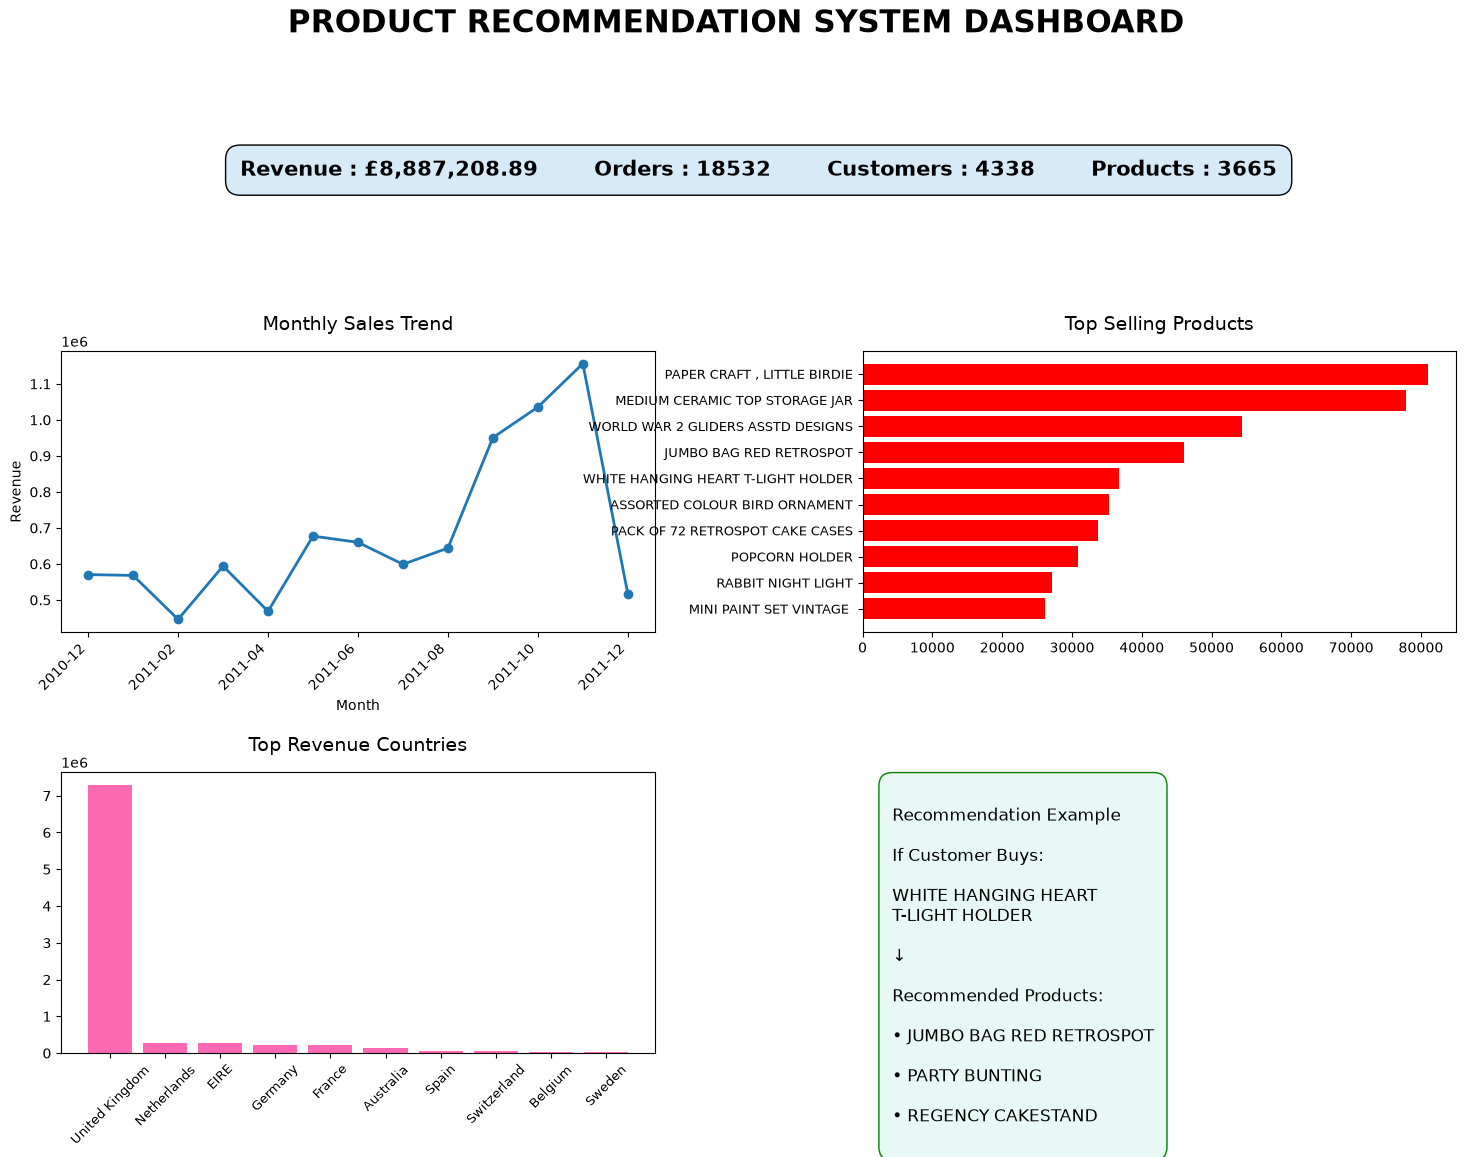

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ===========================
# CREATE DASHBOARD
# ===========================

fig = plt.figure(figsize=(18,12))

gs = gridspec.GridSpec(
    3,
    2,
    height_ratios=[0.35,1.2,1.2],
    hspace=0.65,
    wspace=0.35
)


fig.suptitle(
    "PRODUCT RECOMMENDATION SYSTEM DASHBOARD",
    fontsize=22,
    fontweight='bold',
    y=0.98
)


# ===========================
# KPI BOX
# ===========================

ax0 = fig.add_subplot(gs[0,:])
ax0.axis('off')


kpi_text = (
    f"Revenue : £{total_revenue:,.2f}        "
    f"Orders : {total_orders}        "
    f"Customers : {total_customers}        "
    f"Products : {total_products}"
)


ax0.text(
    0.5,
    0.5,
    kpi_text,
    fontsize=15,
    weight='bold',
    ha='center',
    va='center',
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#D6EAF8",
        edgecolor="black"
    )
)



# ===========================
# SALES TREND
# ===========================

ax1 = fig.add_subplot(gs[1,0])


ax1.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o',
    linewidth=2
)


ax1.set_title(
    "Monthly Sales Trend",
    fontsize=14,
    pad=15
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")


# Show fewer x labels
ax1.set_xticks(
    range(0,len(monthly_sales.index),2)
)

ax1.set_xticklabels(
    monthly_sales.index.astype(str)[::2],
    rotation=45,
    ha='right'
)



# ===========================
# TOP PRODUCTS
# ===========================

ax2 = fig.add_subplot(gs[1,1])


ax2.barh(
    top_products.index[::-1],
    top_products.values[::-1],
    color='red'
)


ax2.set_title(
    "Top Selling Products",
    fontsize=14,
    pad=15
)


ax2.tick_params(axis='y', labelsize=9)



# ===========================
# COUNTRY REVENUE
# ===========================

ax3 = fig.add_subplot(gs[2,0])


ax3.bar(
    country_sales.index,
    country_sales.values,
    color='hotpink'
)


ax3.set_title(
    "Top Revenue Countries",
    fontsize=14,
    pad=15
)


ax3.tick_params(
    axis='x',
    rotation=45,
    labelsize=9
)



# ===========================
# RECOMMENDATION BOX
# ===========================

ax4 = fig.add_subplot(gs[2,1])

ax4.axis('off')


recommendation_text = """
Recommendation Example

If Customer Buys:

WHITE HANGING HEART
T-LIGHT HOLDER

↓

Recommended Products:

• JUMBO BAG RED RETROSPOT

• PARTY BUNTING

• REGENCY CAKESTAND
"""


ax4.text(
    0.05,
    0.95,
    recommendation_text,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#E8F8F5",
        edgecolor="green"
    )
)



plt.tight_layout(rect=[0,0,1,0.95])

plt.show()